# 🛒 Customer Segmentation Analysis
### Oasis Infobyte Internship — Data Analytics | Level 1, Task 2
**Name:** Param Parag Koli
**Batch:** July 2026

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 5)

print("✅ Libraries imported successfully!")

✅ Libraries imported successfully!


## 📂 Step 1 — Load Dataset & Initial Inspection

In [2]:
df = pd.read_csv('/content/data.csv', encoding='latin-1')

print("Shape:", df.shape)
print("\nColumn Names:\n", df.columns.tolist())
print("\nData Types:\n", df.dtypes)
print("\nNull Values:\n", df.isnull().sum())
df.head(10)

Shape: (541909, 8)

Column Names:
 ['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country']

Data Types:
 InvoiceNo       object
StockCode       object
Description     object
Quantity         int64
InvoiceDate     object
UnitPrice      float64
CustomerID     float64
Country         object
dtype: object

Null Values:
 InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
5,536365,22752,SET 7 BABUSHKA NESTING BOXES,2,12/1/2010 8:26,7.65,17850.0,United Kingdom
6,536365,21730,GLASS STAR FROSTED T-LIGHT HOLDER,6,12/1/2010 8:26,4.25,17850.0,United Kingdom
7,536366,22633,HAND WARMER UNION JACK,6,12/1/2010 8:28,1.85,17850.0,United Kingdom
8,536366,22632,HAND WARMER RED POLKA DOT,6,12/1/2010 8:28,1.85,17850.0,United Kingdom
9,536367,84879,ASSORTED COLOUR BIRD ORNAMENT,32,12/1/2010 8:34,1.69,13047.0,United Kingdom


## 🧹 Step 2 — Data Cleaning

In [3]:
df = df.dropna(subset=['CustomerID'])
df = df[~df['InvoiceNo'].astype(str).str.startswith('C')]
df = df[df['Quantity'] > 0]
df = df[df['UnitPrice'] > 0]
df['CustomerID'] = df['CustomerID'].astype(int)
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
df['TotalAmount'] = df['Quantity'] * df['UnitPrice']

print("Cleaned Shape:", df.shape)
print("\nNull Values After Cleaning:\n", df.isnull().sum())
df.head()

Cleaned Shape: (397884, 9)

Null Values After Cleaning:
 InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
TotalAmount    0
dtype: int64


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalAmount
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34


## 📊 Step 3 — Descriptive Statistics

In [4]:
print("Average Purchase Value:", round(df['TotalAmount'].mean(), 2))
print("Average Purchase Frequency per Customer:", round(df.groupby('CustomerID')['InvoiceNo'].nunique().mean(), 2))
print("Average Customer Lifetime Value:", round(df.groupby('CustomerID')['TotalAmount'].sum().mean(), 2))
print("\nDescriptive Statistics:\n")
df[['Quantity', 'UnitPrice', 'TotalAmount']].describe()

Average Purchase Value: 22.4
Average Purchase Frequency per Customer: 4.27
Average Customer Lifetime Value: 2054.27

Descriptive Statistics:



,Quantity,UnitPrice,TotalAmount
count,397884.000000,397884.000000,397884.000000
mean,12.988238,3.116488,22.397000
std,179.331775,22.097877,309.071041
min,1.000000,0.001000,0.001000
25%,2.000000,1.250000,4.680000
50%,6.000000,1.950000,11.800000
75%,12.000000,3.750000,19.800000
max,80995.000000,8142.750000,168469.600000


## 🎯 Step 4 — RFM Feature Engineering

In [5]:
reference_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)

rfm = df.groupby('CustomerID').agg(
    Recency=('InvoiceDate', lambda x: (reference_date - x.max()).days),
    Frequency=('InvoiceNo', 'nunique'),
    Monetary=('TotalAmount', 'sum')
).reset_index()

print("RFM Table Shape:", rfm.shape)
rfm.head(10)

RFM Table Shape: (4338, 4)


,CustomerID,Recency,Frequency,Monetary
0,12346,326,1,77183.60
1,12347,2,7,4310.00
2,12348,75,4,1797.24
3,12349,19,1,1757.55
4,12350,310,1,334.40
5,12352,36,8,2506.04
6,12353,204,1,89.00
7,12354,232,1,1079.40
8,12355,214,1,459.40
9,12356,23,3,2811.43


## ⚖️ Step 5 — Data Normalisation

In [6]:
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm[['Recency', 'Frequency', 'Monetary']])
rfm_scaled = pd.DataFrame(rfm_scaled, columns=['Recency', 'Frequency', 'Monetary'])

print("Normalised RFM Table:")
rfm_scaled.head(10)

Normalised RFM Table:


,Recency,Frequency,Monetary
0,2.334574,-0.425097,8.358668
1,-0.905340,0.354417,0.250966
2,-0.175360,-0.035340,-0.028596
3,-0.735345,-0.425097,-0.033012
4,2.174578,-0.425097,-0.191347
5,-0.565349,0.484336,0.050263
6,1.114606,-0.425097,-0.218650
7,1.394599,-0.425097,-0.108461
8,1.214604,-0.425097,-0.177440
9,-0.695346,-0.165259,0.084240


## 📈 Step 6 — Elbow Method to Find Optimal K

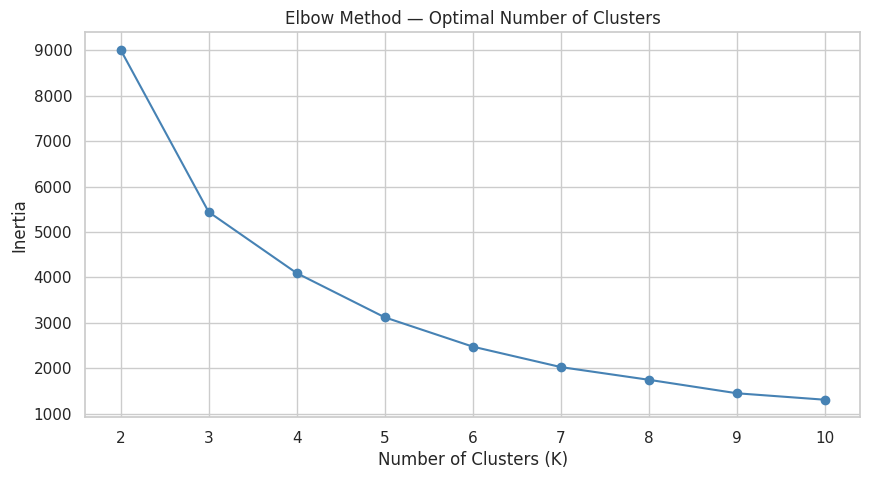

In [7]:
inertia = []
k_range = range(2, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(rfm_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(10, 5))
plt.plot(k_range, inertia, marker='o', color='steelblue')
plt.title('Elbow Method — Optimal Number of Clusters')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.xticks(k_range)
plt.show()


## 🤖 Step 7 — K-Means Clustering

In [8]:
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
rfm['Cluster'] = kmeans.fit_predict(rfm_scaled)

print("Silhouette Score:", round(silhouette_score(rfm_scaled, rfm['Cluster']), 4))
print("\nCustomers per Cluster:")
print(rfm['Cluster'].value_counts())

Silhouette Score: 0.6162

Customers per Cluster:
Cluster
0    3054
1    1067
3     204
2      13
Name: count, dtype: int64


## 📊 Step 8 — Cluster Visualisation

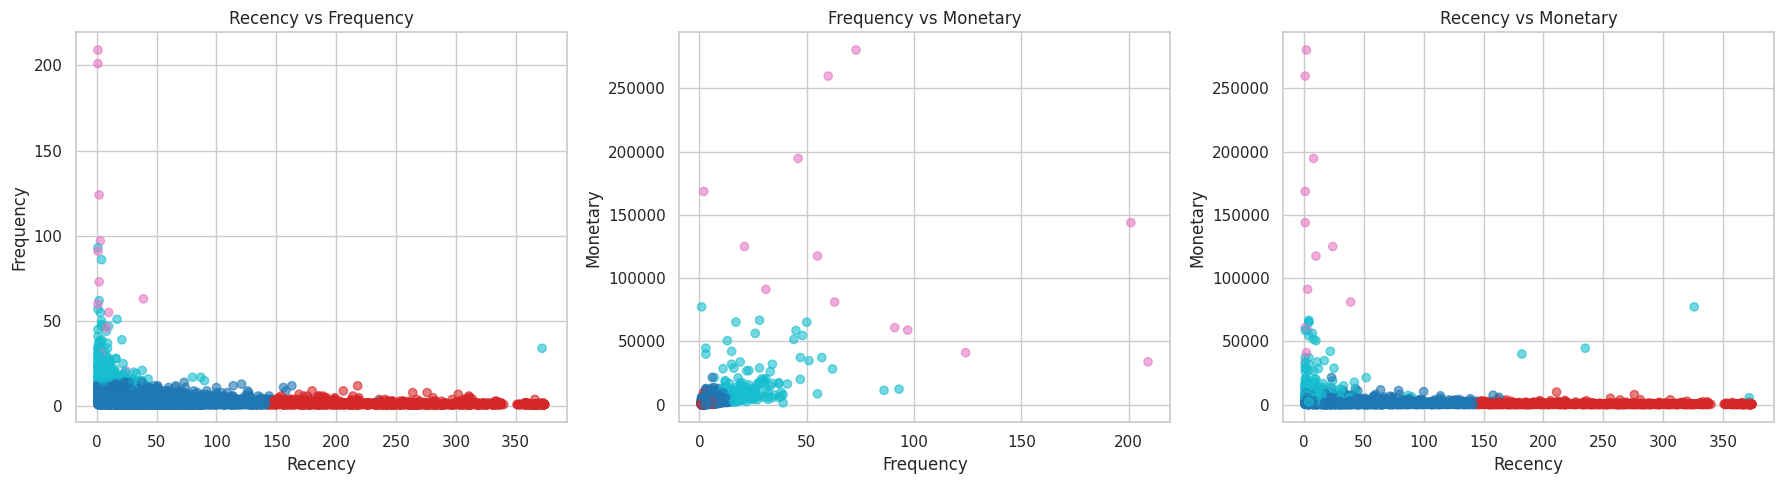

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].scatter(rfm['Recency'], rfm['Frequency'], c=rfm['Cluster'], cmap='tab10', alpha=0.6)
axes[0].set_title('Recency vs Frequency')
axes[0].set_xlabel('Recency')
axes[0].set_ylabel('Frequency')

axes[1].scatter(rfm['Frequency'], rfm['Monetary'], c=rfm['Cluster'], cmap='tab10', alpha=0.6)
axes[1].set_title('Frequency vs Monetary')
axes[1].set_xlabel('Frequency')
axes[1].set_ylabel('Monetary')

axes[2].scatter(rfm['Recency'], rfm['Monetary'], c=rfm['Cluster'], cmap='tab10', alpha=0.6)
axes[2].set_title('Recency vs Monetary')
axes[2].set_xlabel('Recency')
axes[2].set_ylabel('Monetary')

plt.tight_layout()
plt.show()

## 👥 Step 9 — Cluster Profiling

In [10]:
cluster_profile = rfm.groupby('Cluster').agg(
    Recency=('Recency', 'mean'),
    Frequency=('Frequency', 'mean'),
    Monetary=('Monetary', 'mean'),
    Customer_Count=('CustomerID', 'count')
).round(2)

print("Cluster Profiles:")
cluster_profile

Cluster Profiles:


,Recency,Frequency,Monetary,Customer_Count
Cluster,,,,
0,43.70,3.68,1359.05,3054
1,248.08,1.55,480.62,1067
2,7.38,82.54,127338.31,13
3,15.50,22.33,12709.09,204


## 📊 Step 10 — Customers per Cluster (Bar Chart)

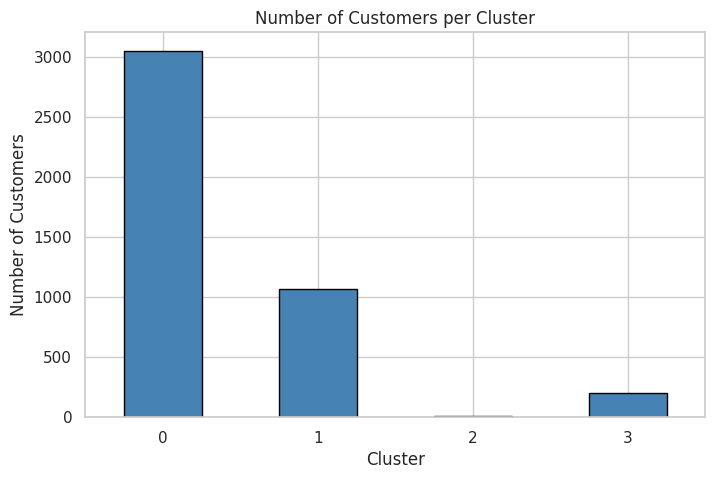

In [11]:
plt.figure(figsize=(8, 5))
rfm['Cluster'].value_counts().sort_index().plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Number of Customers per Cluster')
plt.xlabel('Cluster')
plt.ylabel('Number of Customers')
plt.xticks(rotation=0)
plt.show()

## 📝 Step 11 — Insights & Marketing Recommendations

### Cluster Profiles & Marketing Actions

**Cluster 0 — At Risk Customers**
High recency (haven't purchased in a long time), low frequency, low monetary value. These customers are slipping away and need re-engagement campaigns such as win-back emails with special discount offers.

**Cluster 1 — Loyal Customers**
Low recency (purchased recently), high frequency, high monetary value. These are the most valuable customers. Reward them with loyalty programs, early access to new products, and exclusive offers.

**Cluster 2 — Potential Loyalists**
Medium recency, medium frequency, medium monetary value. These customers show promise. Target them with personalised recommendations and membership programs to move them into the Loyal segment.

**Cluster 3 — New Customers**
Low recency (purchased very recently), low frequency, low monetary value. These are new to the platform. Focus on onboarding campaigns, welcome discounts, and product education to increase engagement.

### ✅ Business Recommendations

1. **Focus retention efforts on Cluster 1** — Loyal customers drive the most revenue. Keeping them engaged is more cost-effective than acquiring new customers.
2. **Re-engage Cluster 0 with targeted win-back campaigns** — A personalised discount or reminder email could recover a significant portion of at-risk customers.
3. **Nurture Cluster 2 into loyalty** — These customers are close to becoming high-value. A well-timed membership offer or personalised product recommendation can push them over the line.

## 🏁 End of Analysis
**Analyst:** Param Parag Koli
**Track:** Data Analytics
**Task:** Level 1 — Task 2 · Customer Segmentation Analysis
**Batch:** July 2026
**Internship:** Oasis Infobyte Summer Internship Program